---
## 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋을 추가로 활용할 수 있음.  
- 참고: https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION

### B. Feature(descriptor)의 다양성
- RDKit 2D descriptor
- Morgan fingerprint
- 필요 시 VEGA 등 외부 descriptor 추가 가능

### 추가 설명
이 노트북은 수업 교안의 `skin_irritation.xlsx`, `skin_irritation_cleaned.csv`, `skin_irritation_2Ddesc.csv` 흐름을 참고하여 작성한 데이터 파이프라인입니다.


# 기말고사 Template 1 - Data Pipeline

**이름:** 20251269 &nbsp; **학번:** 김서율

---

## 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---:|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전 중복 화합물 체크, SMILES 코드 정리 등 필수 확인 사항을 점검 |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 및 주석** | 5점 | 변수의 의미와 코드의 간결성 |

## 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + 선택적 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  
  `Chemical_Name`, `SMILES`, `label`, 2D descriptor, fingerprint 등을 포함


## 0. 분석 목표와 전체 흐름

목표는 피부 자극(skin irritation) 데이터를 모델 개발에 사용할 수 있는 표 형태 데이터셋으로 정리하는 것입니다.

1. NTP ICE 피부 자극 데이터 로딩
2. 사람 대상 Chemical 데이터 선택
3. `Response`를 이진 라벨(`label`: 0/1)로 변환
4. SMILES 표준화, 염 제거, 중복 및 라벨 충돌 제거
5. RDKit 2D descriptor와 Morgan fingerprint 계산
6. 라벨 분포와 주요 descriptor 분포 시각화
7. `final_dataset_descriptors.csv` 저장


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, DataStructs
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import rdFingerprintGenerator

warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

PROJECT_DIR = Path.home() / 'ML'
COURSE_DIR = PROJECT_DIR / '수업'
OUTPUT_DIR = PROJECT_DIR

print('PROJECT_DIR:', PROJECT_DIR)
print('COURSE_DIR:', COURSE_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


PROJECT_DIR: C:\Users\DS\ML
COURSE_DIR: C:\Users\DS\ML\수업
OUTPUT_DIR: C:\Users\DS\ML


## 1. 데이터 불러오기

수업에서는 `skin_irritation.xlsx`의 `Data_invivo` 시트를 사용했습니다. 실행 환경에 `openpyxl`이 없으면 엑셀 파일을 바로 읽지 못하므로, 같은 수업 폴더에 있는 정리된 CSV를 자동으로 사용하도록 했습니다.


In [2]:
def load_skin_irritation_data():
    """엑셀 원본을 우선 사용하고, 실패하면 수업에서 만든 CSV를 사용한다."""
    xlsx_path = COURSE_DIR / 'skin_irritation.xlsx'
    cleaned_csv_path = COURSE_DIR / 'skin_irritation_cleaned.csv'
    final_csv_path = COURSE_DIR / 'final_skin_irritation_analysis.csv'

    if xlsx_path.exists():
        try:
            df_xlsx = pd.read_excel(xlsx_path, sheet_name='Data_invivo')
            return df_xlsx, xlsx_path.name
        except Exception as exc:
            print('엑셀 로딩 실패:', type(exc).__name__, exc)
            print('CSV fallback을 사용합니다.')

    if cleaned_csv_path.exists():
        return pd.read_csv(cleaned_csv_path), cleaned_csv_path.name

    if final_csv_path.exists():
        return pd.read_csv(final_csv_path), final_csv_path.name

    raise FileNotFoundError('skin_irritation.xlsx 또는 수업 CSV 파일을 찾을 수 없습니다.')

raw_df, source_name = load_skin_irritation_data()
raw_df.columns = raw_df.columns.str.strip()

print('사용한 데이터:', source_name)
print('raw shape:', raw_df.shape)
display(raw_df.head())


엑셀 로딩 실패: ImportError `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.
CSV fallback을 사용합니다.
사용한 데이터: skin_irritation_cleaned.csv
raw shape: (81, 27)


,Unnamed: 0,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,...,Endpoint,Response,Response_Unit,Reference,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS,label
0,82,skin_irritation_invivo_84,In Vivo,NaN,NaN,Propylene glycol,57-55-6,DTXSID0021206,NaN,NaN,...,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CC(O)CO,"1,2-Propylene glycol","57-55-6|1,2-Propylene glycol|(.+-.)-1,2-Propan...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0021206,0
1,100,skin_irritation_invivo_12,In Vivo,NaN,NaN,Heptanal,111-71-7,DTXSID0021597,NaN,NaN,...,Qualitative classification,Irritant,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,CCCCCCC=O,Heptanal,111-71-7|Heptanal|1-Heptaldehyde|1-Heptanal|Al...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0021597,1
2,130,skin_irritation_invivo_33,In Vivo,NaN,NaN,Isopropyl myristate,110-27-0,DTXSID0026838,NaN,NaN,...,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CCCCCCCCCCCCCC(=O)OC(C)C,Isopropyl tetradecanoate,110-27-0|Isopropyl tetradecanoate|1-Methylethy...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0
3,132,skin_irritation_invivo_67,In Vivo,NaN,NaN,di-Propylene glycol,25265-71-8,DTXSID0027856,NaN,NaN,...,Qualitative classification,Not classified,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,"C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|",Dipropylene glycol,"25265-71-8|Dipropylene glycol|1,1'-Oxybis(2-pr...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0027856,0
4,146,skin_irritation_invivo_63,In Vivo,NaN,NaN,Sodium hydroxide,1310-73-2,DTXSID0029634,NaN,NaN,...,Qualitative classification,Irritant/Possible corrosive,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,[OH-].[Na+],Sodium hydroxide,1310-73-2|Sodium hydroxide|Aetznatron|ANHYDROU...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,1


## 2. 데이터 분포 확인

모델을 만들기 전에 데이터가 어떤 `Mixture`, `Species`, `Endpoint`, `Response`로 구성되어 있는지 먼저 확인합니다. 이 단계는 수업에서 사용한 `value_counts()` 기반 데이터 점검과 같습니다.


In [3]:
check_cols = ['Mixture', 'Species', 'Endpoint', 'Response', 'label']

for col in check_cols:
    if col in raw_df.columns:
        print(f'[{col}]')
        display(raw_df[col].value_counts(dropna=False).head(15).to_frame('count'))
        print()


[Mixture]


,count
Mixture,
Chemical,81



[Species]


,count
Species,
Human,81



[Endpoint]


,count
Endpoint,
Qualitative classification,50
Positive reaction,31



[Response]


,count
Response,
Not classified,38
0,18
Irritant,7
Not classified/Possible irritant,3
Irritant/Possible corrosive,2
17.90,2
6.25,1
3.3,1
83.1,1



[label]


,count
label,
0,56
1,25


## 3. 모델 개발용 데이터 선택과 라벨 생성

수업 흐름에 맞춰 다음 조건을 우선 적용합니다.

- `Mixture == Chemical`
- `Species == Human`
- `Endpoint == Qualitative classification`이 있으면 해당 endpoint 사용
- 이미 `label` 컬럼이 있으면 그대로 사용
- 없으면 `Response`에서 `Not classified`는 0, 그 외는 1로 변환


In [4]:
def normalize_text(series):
    return series.astype(str).str.strip().str.lower()

work_df = raw_df.copy()

if 'Mixture' in work_df.columns:
    work_df = work_df[normalize_text(work_df['Mixture']) == 'chemical'].copy()

if 'Species' in work_df.columns:
    work_df = work_df[normalize_text(work_df['Species']) == 'human'].copy()

if 'Endpoint' in work_df.columns:
    endpoints = normalize_text(work_df['Endpoint'])
    if (endpoints == 'qualitative classification').any():
        work_df = work_df[endpoints == 'qualitative classification'].copy()

if 'label' not in work_df.columns:
    def make_label(response):
        text = str(response).strip().lower()
        numeric = pd.to_numeric(text, errors='coerce')
        if pd.notna(numeric):
            return int(numeric > 0)
        if text in ['not classified', 'negative', 'non-irritant', 'no irritation']:
            return 0
        return 1

    work_df['label'] = work_df['Response'].apply(make_label)
else:
    work_df['label'] = pd.to_numeric(work_df['label'], errors='coerce')

work_df = work_df.dropna(subset=['label']).copy()
work_df['label'] = work_df['label'].astype(int)

needed_cols = [c for c in ['Chemical_Name', 'SMILES', 'Response', 'Endpoint', 'label'] if c in work_df.columns]
print('선택 후 shape:', work_df.shape)
display(work_df[needed_cols].head())
print('label 분포:')
display(work_df['label'].value_counts().sort_index().to_frame('count'))


선택 후 shape: (50, 27)


,Chemical_Name,SMILES,Response,Endpoint,label
0,Propylene glycol,CC(O)CO,Not classified,Qualitative classification,0
1,Heptanal,CCCCCCC=O,Irritant,Qualitative classification,1
2,Isopropyl myristate,CCCCCCCCCCCCCC(=O)OC(C)C,Not classified,Qualitative classification,0
3,di-Propylene glycol,"C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|",Not classified,Qualitative classification,0
4,Sodium hydroxide,[OH-].[Na+],Irritant/Possible corrosive,Qualitative classification,1


label 분포:


,count
label,
0,38
1,12


## 4. SMILES 정리: 결측치, CXSMILES, 염/fragment, 중복 제거

SMILES는 descriptor 계산의 출발점이므로 다음을 처리합니다.

- SMILES 결측 제거
- `|`가 포함된 CXSMILES 형태 제거
- RDKit으로 읽히지 않는 SMILES 제거
- 여러 fragment가 있으면 가장 큰 fragment 선택
- canonical SMILES(`standardized_smi`)로 표준화
- 같은 표준화 SMILES가 서로 다른 label을 가지는 충돌 데이터 제거
- 같은 표준화 SMILES 중복은 1개만 유지


In [5]:
if 'SMILES' not in work_df.columns:
    raise KeyError('SMILES 컬럼이 없어 descriptor 계산을 진행할 수 없습니다.')

before_missing = len(work_df)
work_df = work_df.dropna(subset=['SMILES']).copy()
work_df['SMILES'] = work_df['SMILES'].astype(str).str.strip()
work_df = work_df[work_df['SMILES'] != ''].copy()
removed_missing = before_missing - len(work_df)

before_cx = len(work_df)
work_df = work_df[~work_df['SMILES'].str.contains('|', regex=False, na=False)].copy()
removed_cx = before_cx - len(work_df)

fragment_chooser = rdMolStandardize.LargestFragmentChooser()

def standardize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        mol = fragment_chooser.choose(mol)
        if mol is None or mol.GetNumAtoms() == 0:
            return None
        return Chem.MolToSmiles(mol, isomericSmiles=True)
    except Exception:
        return None

work_df['standardized_smi'] = work_df['SMILES'].apply(standardize_smiles)

before_invalid = len(work_df)
work_df = work_df.dropna(subset=['standardized_smi']).copy()
removed_invalid = before_invalid - len(work_df)

label_nunique = work_df.groupby('standardized_smi')['label'].transform('nunique')
conflict_df = work_df[label_nunique > 1].copy()
consistent_df = work_df[label_nunique == 1].copy()

before_duplicate = len(consistent_df)
clean_df = consistent_df.drop_duplicates(subset='standardized_smi').copy()
removed_duplicate = before_duplicate - len(clean_df)

print('[전처리 요약]')
print(f'SMILES 결측/빈값 제거: {removed_missing}')
print(f'CXSMILES(| 포함) 제거: {removed_cx}')
print(f'RDKit 변환 실패 제거: {removed_invalid}')
print(f'라벨 충돌 화합물 row 수: {len(conflict_df)}')
print(f'중복 표준화 SMILES 제거: {removed_duplicate}')
print(f'최종 화합물 수: {len(clean_df)}')

summary_cols = [c for c in ['Chemical_Name', 'SMILES', 'standardized_smi', 'Response', 'label'] if c in clean_df.columns]
display(clean_df[summary_cols].head())
display(clean_df['label'].value_counts().sort_index().to_frame('count'))


[전처리 요약]
SMILES 결측/빈값 제거: 0
CXSMILES(| 포함) 제거: 3
RDKit 변환 실패 제거: 0
라벨 충돌 화합물 row 수: 0
중복 표준화 SMILES 제거: 1
최종 화합물 수: 46


,Chemical_Name,SMILES,standardized_smi,Response,label
0,Propylene glycol,CC(O)CO,CC(O)CO,Not classified,0
1,Heptanal,CCCCCCC=O,CCCCCCC=O,Irritant,1
2,Isopropyl myristate,CCCCCCCCCCCCCC(=O)OC(C)C,CCCCCCCCCCCCCC(=O)OC(C)C,Not classified,0
4,Sodium hydroxide,[OH-].[Na+],[OH-],Irritant/Possible corrosive,1
5,4-Methylthio benzaldehyde,CSC1=CC=C(C=O)C=C1,CSc1ccc(C=O)cc1,Not classified,0


,count
label,
0,34
1,12


## 5. RDKit 2D descriptor 계산

수업의 `Descriptors.CalcMolDescriptors()` 방식으로 RDKit 2D descriptor를 계산합니다. 계산된 descriptor는 모델에서 feature로 사용할 수 있는 숫자 데이터입니다.


In [6]:
def calc_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {}
    return dict(Descriptors.CalcMolDescriptors(mol))

desc_rows = []
for smi in clean_df['standardized_smi']:
    desc_rows.append(calc_rdkit_descriptors(smi))

desc_df = pd.DataFrame(desc_rows)
desc_df = desc_df.apply(pd.to_numeric, errors='coerce')

id_cols = ['Chemical_Name', 'SMILES', 'standardized_smi', 'label']
id_cols = [c for c in id_cols if c in clean_df.columns]

rdkit_dataset = pd.concat(
    [clean_df[id_cols].reset_index(drop=True), desc_df.reset_index(drop=True)],
    axis=1,
)

print('descriptor 개수:', desc_df.shape[1])
print('rdkit_dataset shape:', rdkit_dataset.shape)
display(rdkit_dataset.head())


descriptor 개수: 217
rdkit_dataset shape: (46, 221)


,Chemical_Name,SMILES,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Propylene glycol,CC(O)CO,CC(O)CO,0,8.111111,8.111111,0.138889,-0.560185,0.435835,15.000000,...,0,0,0,0,0,0,0,0,0,0
1,Heptanal,CCCCCCC=O,CCCCCCC=O,1,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,...,0,0,0,0,0,0,0,0,4,0
2,Isopropyl myristate,CCCCCCCCCCCCCC(=O)OC(C)C,CCCCCCCCCCCCCC(=O)OC(C)C,0,11.291588,11.291588,0.027971,-0.036181,0.319642,10.947368,...,0,0,0,0,0,0,0,0,10,0
3,Sodium hydroxide,[OH-].[Na+],[OH-],1,0.000000,0.000000,0.000000,0.000000,0.357116,0.000000,...,0,0,0,0,0,0,0,0,0,0
4,4-Methylthio benzaldehyde,CSC1=CC=C(C=O)C=C1,CSc1ccc(C=O)cc1,0,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,...,1,0,0,0,0,0,0,0,0,0


## 6. Morgan fingerprint 계산

Descriptor 다양성을 높이기 위해 Morgan fingerprint(radius=2, 2048 bits)를 추가합니다. Fingerprint는 분자의 부분 구조 존재 여부를 bit 형태로 표현합니다.


In [7]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def fingerprint_to_array(smiles):
    mol = Chem.MolFromSmiles(smiles)
    arr = np.zeros((2048,), dtype=np.int8)
    if mol is None:
        return arr
    fp = morgan_generator.GetFingerprint(mol)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_array = np.vstack(clean_df['standardized_smi'].apply(fingerprint_to_array).to_numpy())
fp_df = pd.DataFrame(fp_array, columns=[f'morgan_{i}' for i in range(fp_array.shape[1])])

print('fingerprint shape:', fp_df.shape)
display(fp_df.iloc[:5, :12])


fingerprint shape: (46, 2048)


,morgan_0,morgan_1,morgan_2,morgan_3,morgan_4,morgan_5,morgan_6,morgan_7,morgan_8,morgan_9,morgan_10,morgan_11
0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


## 7. 최종 데이터셋 저장

최종 산출물은 `Chemical_Name`, `SMILES`, `label`, RDKit 2D descriptor, Morgan fingerprint를 포함합니다. 모델 학습 때 fingerprint가 너무 많다고 판단되면 `morgan_` 컬럼을 제외하고 2D descriptor만 사용할 수 있습니다.


In [8]:
final_dataset = pd.concat(
    [rdkit_dataset.reset_index(drop=True), fp_df.reset_index(drop=True)],
    axis=1,
)

output_path = OUTPUT_DIR / 'final_dataset_descriptors.csv'
rdkit_only_path = OUTPUT_DIR / 'final_dataset_rdkit_2d_descriptors.csv'
clean_path = OUTPUT_DIR / 'final_dataset_cleaned_compounds.csv'

final_dataset.to_csv(output_path, index=False, encoding='utf-8-sig')
rdkit_dataset.to_csv(rdkit_only_path, index=False, encoding='utf-8-sig')
clean_df.to_csv(clean_path, index=False, encoding='utf-8-sig')

print('저장 완료:')
print('-', output_path)
print('-', rdkit_only_path)
print('-', clean_path)
print('final_dataset shape:', final_dataset.shape)


저장 완료:


- C:\Users\DS\ML\final_dataset_descriptors.csv
- C:\Users\DS\ML\final_dataset_rdkit_2d_descriptors.csv
- C:\Users\DS\ML\final_dataset_cleaned_compounds.csv
final_dataset shape: (46, 2269)



## 8. 추가 NTP ICE 데이터 활용 - 데이터 다양성 보강

가산점 항목인 데이터 다양성을 위해 NTP ICE에서 추가로 받은 `eye_irritation.xlsx`, `endocrine.xlsx`, `cancer.xlsx`를 검토했습니다.

단일 skin irritation 모델에 서로 다른 독성 endpoint를 무작정 섞으면 `label`의 의미가 달라져 모델 목적이 흐려질 수 있습니다. 따라서 추가 데이터는 `task` 컬럼을 둔 multi-task 보조 데이터셋으로 정리합니다.

사용 판단:

- `eye_irritation.xlsx`: `GHS Classification`은 피부 자극과 가까운 자극성 endpoint이므로 활용 가치가 큼
- `endocrine.xlsx`: `Call` endpoint가 `Active`/`Inactive`로 명확해 보조 독성 task로 활용 가능
- `cancer.xlsx`: `Cancer classification`은 문구가 다양해 직접 이진화 위험이 큼. 대신 `Bacterial mutagenicity` endpoint의 Positive/Negative 중심 데이터만 사용

엑셀 로딩은 `openpyxl`이 있으면 pandas를 사용하고, 없으면 아래의 간단한 xlsx reader로 읽습니다.


In [9]:

import zipfile
import xml.etree.ElementTree as ET

XLSX_NS = {
    'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main',
    'r': 'http://schemas.openxmlformats.org/officeDocument/2006/relationships',
}


def excel_col_to_index(cell_ref):
    letters = ''.join(ch for ch in cell_ref if ch.isalpha())
    index = 0
    for ch in letters:
        index = index * 26 + ord(ch.upper()) - 64
    return index - 1


def read_xlsx_without_openpyxl(path, sheet_name):
    """openpyxl이 없을 때 xlsx 내부 XML을 읽어 DataFrame으로 변환한다."""
    path = Path(path)
    with zipfile.ZipFile(path) as zf:
        shared = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            root = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for item in root.findall('a:si', XLSX_NS):
                text = ''.join(
                    node.text or ''
                    for node in item.iter('{http://schemas.openxmlformats.org/spreadsheetml/2006/main}t')
                )
                shared.append(text)

        workbook = ET.fromstring(zf.read('xl/workbook.xml'))
        rels = ET.fromstring(zf.read('xl/_rels/workbook.xml.rels'))
        rel_map = {rel.attrib['Id']: rel.attrib['Target'] for rel in rels}

        sheet_target = None
        for sheet in workbook.find('a:sheets', XLSX_NS):
            if sheet.attrib['name'] == sheet_name:
                rid = sheet.attrib['{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id']
                target = rel_map[rid]
                sheet_target = 'xl/' + target.lstrip('/') if not target.startswith('xl/') else target
                break

        if sheet_target is None:
            raise ValueError(f'{path.name}에서 {sheet_name} 시트를 찾을 수 없습니다.')

        sheet_root = ET.fromstring(zf.read(sheet_target))
        raw_rows = []
        width = 0

        for row in sheet_root.findall('.//a:sheetData/a:row', XLSX_NS):
            values = {}
            max_col = -1
            for cell in row.findall('a:c', XLSX_NS):
                col_index = excel_col_to_index(cell.attrib.get('r', 'A1'))
                max_col = max(max_col, col_index)
                cell_type = cell.attrib.get('t')
                value_node = cell.find('a:v', XLSX_NS)

                if cell_type == 's' and value_node is not None:
                    value = shared[int(value_node.text)]
                elif cell_type == 'inlineStr':
                    value = ''.join(
                        node.text or ''
                        for node in cell.iter('{http://schemas.openxmlformats.org/spreadsheetml/2006/main}t')
                    )
                elif value_node is not None:
                    value = value_node.text
                else:
                    value = ''

                values[col_index] = value

            if values:
                width = max(width, max_col + 1)
                raw_rows.append(values)

        table = [[row.get(i, '') for i in range(width)] for row in raw_rows]

    header = table[0]
    rows = table[1:]
    return pd.DataFrame(rows, columns=header)


def read_ntp_excel(path, sheet_name):
    """pandas read_excel을 먼저 시도하고, 실패하면 XML reader로 fallback한다."""
    try:
        return pd.read_excel(path, sheet_name=sheet_name)
    except Exception as exc:
        print(f'{Path(path).name} 엑셀 직접 로딩 실패: {type(exc).__name__}. XML fallback 사용')
        return read_xlsx_without_openpyxl(path, sheet_name)


In [10]:

def label_eye_ghs(response):
    text = str(response).strip().lower()
    if text in ['', 'nan']:
        return np.nan
    if text in ['not classified', '0']:
        return 0
    return 1


def label_active_inactive(response):
    text = str(response).strip().lower()
    if text == 'active':
        return 1
    if text == 'inactive':
        return 0
    return np.nan


def label_mutagenicity(response):
    text = str(response).strip().lower()
    if not text or text == 'nan':
        return np.nan
    parts = [part.strip() for part in text.split(';')]
    if any('positive' in part for part in parts):
        return 1
    if all(part == 'negative' for part in parts):
        return 0
    return np.nan


extra_configs = [
    {
        'file': 'eye_irritation.xlsx',
        'sheet': 'Data',
        'endpoint': 'GHS Classification',
        'task': 'eye_irritation_ghs',
        'label_func': label_eye_ghs,
        'reason': '피부 자극과 가까운 눈 자극성 분류 데이터',
    },
    {
        'file': 'endocrine.xlsx',
        'sheet': 'Data_invitro',
        'endpoint': 'Call',
        'task': 'endocrine_invitro_call',
        'label_func': label_active_inactive,
        'reason': 'Active/Inactive가 명확한 in vitro endocrine activity 데이터',
    },
    {
        'file': 'endocrine.xlsx',
        'sheet': 'Data_invivo',
        'endpoint': 'Call',
        'task': 'endocrine_invivo_call',
        'label_func': label_active_inactive,
        'reason': 'Active/Inactive가 명확한 in vivo endocrine activity 데이터',
    },
    {
        'file': 'cancer.xlsx',
        'sheet': 'Data',
        'endpoint': 'Bacterial mutagenicity',
        'task': 'cancer_bacterial_mutagenicity',
        'label_func': label_mutagenicity,
        'reason': 'cancer.xlsx 내에서 Positive/Negative 해석이 비교적 명확한 변이원성 데이터',
    },
]

extra_frames = []
extra_summary = []

for config in extra_configs:
    path = COURSE_DIR / config['file']
    df_extra = read_ntp_excel(path, config['sheet'])
    df_extra.columns = df_extra.columns.astype(str).str.strip()

    subset = df_extra.copy()
    if 'Mixture' in subset.columns:
        subset = subset[subset['Mixture'].astype(str).str.strip().str.lower() == 'chemical']
    subset = subset[subset['Endpoint'].astype(str).str.strip() == config['endpoint']]
    subset = subset.dropna(subset=['SMILES']).copy()
    subset['SMILES'] = subset['SMILES'].astype(str).str.strip()
    subset = subset[subset['SMILES'] != '']

    subset['label'] = subset['Response'].apply(config['label_func'])
    subset = subset.dropna(subset=['label']).copy()
    subset['label'] = subset['label'].astype(int)
    subset['task'] = config['task']
    subset['source_file'] = config['file']
    subset['source_sheet'] = config['sheet']
    subset['selection_reason'] = config['reason']

    keep_cols = [
        'task', 'source_file', 'source_sheet', 'selection_reason',
        'Chemical_Name', 'SMILES', 'Endpoint', 'Response', 'label',
        'Species', 'Assay', 'CASRN', 'DTXSID',
    ]
    keep_cols = [col for col in keep_cols if col in subset.columns]
    subset = subset[keep_cols].copy()

    extra_frames.append(subset)
    extra_summary.append({
        'task': config['task'],
        'source': f"{config['file']} / {config['sheet']}",
        'endpoint': config['endpoint'],
        'rows_before_smiles_standardization': len(subset),
        'unique_smiles_before_standardization': subset['SMILES'].nunique(),
        'label_0': int((subset['label'] == 0).sum()),
        'label_1': int((subset['label'] == 1).sum()),
        'reason': config['reason'],
    })

extra_raw = pd.concat(extra_frames, ignore_index=True)
extra_summary_df = pd.DataFrame(extra_summary)

print('추가 데이터 선택 요약')
display(extra_summary_df)
print('추가 데이터 raw shape:', extra_raw.shape)
display(extra_raw.head())


eye_irritation.xlsx 엑셀 직접 로딩 실패: ImportError. XML fallback 사용


endocrine.xlsx 엑셀 직접 로딩 실패: ImportError. XML fallback 사용


endocrine.xlsx 엑셀 직접 로딩 실패: ImportError. XML fallback 사용
cancer.xlsx 엑셀 직접 로딩 실패: ImportError. XML fallback 사용


추가 데이터 선택 요약


,task,source,endpoint,rows_before_smiles_standardization,unique_smiles_before_standardization,label_0,label_1,reason
0,eye_irritation_ghs,eye_irritation.xlsx / Data,GHS Classification,230,175,55,175,피부 자극과 가까운 눈 자극성 분류 데이터
1,endocrine_invitro_call,endocrine.xlsx / Data_invitro,Call,4441,163,1294,3147,Active/Inactive가 명확한 in vitro endocrine activi...
2,endocrine_invivo_call,endocrine.xlsx / Data_invivo,Call,954,217,333,621,Active/Inactive가 명확한 in vivo endocrine activit...
3,cancer_bacterial_mutagenicity,cancer.xlsx / Data,Bacterial mutagenicity,1932,1930,1223,709,cancer.xlsx 내에서 Positive/Negative 해석이 비교적 명확한 ...


추가 데이터 raw shape: (7557, 13)


,task,source_file,source_sheet,selection_reason,Chemical_Name,SMILES,Endpoint,Response,label,Species,Assay,CASRN,DTXSID
0,eye_irritation_ghs,eye_irritation.xlsx,Data,피부 자극과 가까운 눈 자극성 분류 데이터,"1,2-Propylene glycol",CC(O)CO,GHS Classification,Not classified,0,Rabbit,Draize Eye Irritation/Corrosion Test,57-55-6,DTXSID0021206
1,eye_irritation_ghs,eye_irritation.xlsx,Data,피부 자극과 가까운 눈 자극성 분류 데이터,2-Methyl-1-propanol,CC(C)CO,GHS Classification,2A,1,Rabbit,Draize Eye Irritation/Corrosion Test,78-83-1,DTXSID0021759
2,eye_irritation_ghs,eye_irritation.xlsx,Data,피부 자극과 가까운 눈 자극성 분류 데이터,n-Hexane,CCCCCC,GHS Classification,Not classified,0,Rabbit,Draize Eye Irritation/Corrosion Test,110-54-3,DTXSID0021917
3,eye_irritation_ghs,eye_irritation.xlsx,Data,피부 자극과 가까운 눈 자극성 분류 데이터,Ammonia,N,GHS Classification,1,1,Rabbit,Draize Eye Irritation/Corrosion Test,7664-41-7,DTXSID0023872
4,eye_irritation_ghs,eye_irritation.xlsx,Data,피부 자극과 가까운 눈 자극성 분류 데이터,"2,4-Dihydroxybenzoic acid",OC(=O)C1=CC=C(O)C=C1O,GHS Classification,1,1,Rabbit,Draize Eye Irritation/Corrosion Test,89-86-1,DTXSID0025074


In [11]:

# 추가 데이터도 기존 skin irritation과 같은 방식으로 SMILES를 표준화하고 descriptor를 계산한다.
extra_raw = extra_raw[~extra_raw['SMILES'].str.contains('|', regex=False, na=False)].copy()
extra_raw['standardized_smi'] = extra_raw['SMILES'].apply(standardize_smiles)
extra_clean = extra_raw.dropna(subset=['standardized_smi']).copy()

# 같은 task 안에서 같은 구조가 서로 다른 label을 가지면 모델 학습용으로 부적절하므로 제거한다.
label_nunique = extra_clean.groupby(['task', 'standardized_smi'])['label'].transform('nunique')
extra_conflict = extra_clean[label_nunique > 1].copy()
extra_clean = extra_clean[label_nunique == 1].copy()
extra_clean = extra_clean.drop_duplicates(subset=['task', 'standardized_smi']).copy()

extra_desc_rows = []
for smi in extra_clean['standardized_smi']:
    extra_desc_rows.append(calc_rdkit_descriptors(smi))

extra_desc_df = pd.DataFrame(extra_desc_rows).apply(pd.to_numeric, errors='coerce')
extra_id_cols = [
    'task', 'source_file', 'source_sheet', 'Chemical_Name', 'SMILES',
    'standardized_smi', 'Endpoint', 'Response', 'label', 'Species', 'Assay',
]
extra_id_cols = [col for col in extra_id_cols if col in extra_clean.columns]

extra_dataset = pd.concat(
    [extra_clean[extra_id_cols].reset_index(drop=True), extra_desc_df.reset_index(drop=True)],
    axis=1,
)

# skin irritation 데이터도 같은 multi-task 형식으로 맞춰 비교 가능한 통합 파일을 만든다.
skin_task_dataset = rdkit_dataset.copy()
skin_task_dataset.insert(0, 'task', 'skin_irritation_qualitative')
skin_task_dataset.insert(1, 'source_file', source_name)
skin_task_dataset.insert(2, 'source_sheet', 'Data_invivo 또는 수업 CSV')

combined_multitask_dataset = pd.concat(
    [skin_task_dataset, extra_dataset],
    ignore_index=True,
    sort=False,
)

extra_output_path = OUTPUT_DIR / 'additional_ntp_ice_descriptors.csv'
combined_output_path = OUTPUT_DIR / 'final_ntp_ice_multitask_descriptors.csv'
summary_output_path = OUTPUT_DIR / 'additional_ntp_ice_summary.csv'

extra_dataset.to_csv(extra_output_path, index=False, encoding='utf-8-sig')
combined_multitask_dataset.to_csv(combined_output_path, index=False, encoding='utf-8-sig')
extra_summary_df.to_csv(summary_output_path, index=False, encoding='utf-8-sig')

print('추가 데이터 전처리 결과')
print('라벨 충돌로 제외된 row 수:', len(extra_conflict))
print('extra_dataset shape:', extra_dataset.shape)
print('combined_multitask_dataset shape:', combined_multitask_dataset.shape)
print('저장 완료:')
print('-', extra_output_path)
print('-', combined_output_path)
print('-', summary_output_path)

display(extra_dataset.groupby('task')['label'].value_counts().unstack(fill_value=0))


추가 데이터 전처리 결과
라벨 충돌로 제외된 row 수: 4906
extra_dataset shape: (2197, 228)
combined_multitask_dataset shape: (2243, 228)
저장 완료:
- C:\Users\DS\ML\additional_ntp_ice_descriptors.csv
- C:\Users\DS\ML\final_ntp_ice_multitask_descriptors.csv
- C:\Users\DS\ML\additional_ntp_ice_summary.csv


label,0,1
task,,
cancer_bacterial_mutagenicity,1162,679
endocrine_invitro_call,34,13
endocrine_invivo_call,94,50
eye_irritation_ghs,42,123


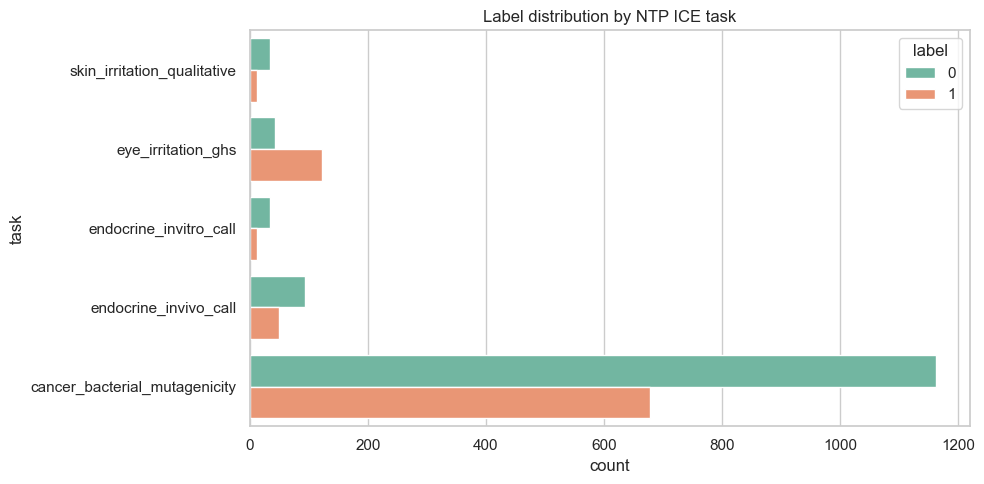

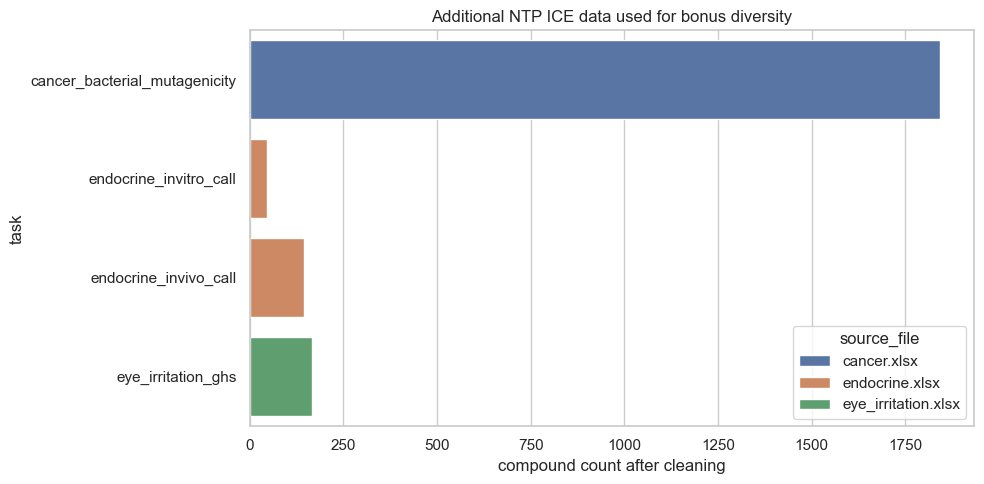

In [12]:

plt.figure(figsize=(10, 5))
plot_df = combined_multitask_dataset[['task', 'label']].dropna().copy()
plot_df['label'] = plot_df['label'].astype(int)
sns.countplot(data=plot_df, y='task', hue='label', palette='Set2')
plt.title('Label distribution by NTP ICE task')
plt.xlabel('count')
plt.ylabel('task')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
source_counts = extra_dataset.groupby(['source_file', 'task']).size().reset_index(name='count')
sns.barplot(data=source_counts, x='count', y='task', hue='source_file')
plt.title('Additional NTP ICE data used for bonus diversity')
plt.xlabel('compound count after cleaning')
plt.ylabel('task')
plt.tight_layout()
plt.show()



## 8. 추가 NTP ICE 데이터 활용 - Skin Sensitization

교수님 피드백을 반영하여 cancer, endocrine, eye irritation 데이터는 추가 데이터셋에서 제외했습니다. 대신 `skin_sensitization.xlsx`를 사용합니다.

Skin irritation과 skin sensitization은 완전히 같은 endpoint는 아니지만, 둘 다 피부 노출 후 발생하는 국소 피부 독성(local skin toxicity)이라는 점에서 관련성이 있습니다.

- **Skin irritation**: 화학물질이 피부에 직접 손상을 주어 나타나는 자극/염증 반응
- **Skin sensitization**: 반복 노출 후 면역계가 관여하는 알레르기성 접촉 과민반응

따라서 두 데이터를 하나의 `label`로 무작정 합치지는 않고, `task` 컬럼을 두어 `skin_irritation`과 `skin_sensitization`을 구분한 multi-task 보조 데이터셋으로 정리합니다. 이렇게 하면 데이터 다양성은 확보하면서도 endpoint의 의미를 혼동하지 않을 수 있습니다.


In [13]:

import zipfile
import xml.etree.ElementTree as ET

XLSX_NS = {
    'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main',
    'r': 'http://schemas.openxmlformats.org/officeDocument/2006/relationships',
}


def excel_col_to_index(cell_ref):
    letters = ''.join(ch for ch in cell_ref if ch.isalpha())
    index = 0
    for ch in letters:
        index = index * 26 + ord(ch.upper()) - 64
    return index - 1


def read_xlsx_without_openpyxl(path, sheet_name):
    """openpyxl이 없을 때 xlsx 내부 XML을 읽어 DataFrame으로 변환한다."""
    path = Path(path)
    with zipfile.ZipFile(path) as zf:
        shared = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            root = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for item in root.findall('a:si', XLSX_NS):
                text = ''.join(
                    node.text or ''
                    for node in item.iter('{http://schemas.openxmlformats.org/spreadsheetml/2006/main}t')
                )
                shared.append(text)

        workbook = ET.fromstring(zf.read('xl/workbook.xml'))
        rels = ET.fromstring(zf.read('xl/_rels/workbook.xml.rels'))
        rel_map = {rel.attrib['Id']: rel.attrib['Target'] for rel in rels}

        sheet_target = None
        for sheet in workbook.find('a:sheets', XLSX_NS):
            if sheet.attrib['name'] == sheet_name:
                rid = sheet.attrib['{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id']
                target = rel_map[rid]
                sheet_target = 'xl/' + target.lstrip('/') if not target.startswith('xl/') else target
                break

        if sheet_target is None:
            raise ValueError(f'{path.name}에서 {sheet_name} 시트를 찾을 수 없습니다.')

        sheet_root = ET.fromstring(zf.read(sheet_target))
        raw_rows = []
        width = 0
        for row in sheet_root.findall('.//a:sheetData/a:row', XLSX_NS):
            values = {}
            max_col = -1
            for cell in row.findall('a:c', XLSX_NS):
                col_index = excel_col_to_index(cell.attrib.get('r', 'A1'))
                max_col = max(max_col, col_index)
                cell_type = cell.attrib.get('t')
                value_node = cell.find('a:v', XLSX_NS)

                if cell_type == 's' and value_node is not None:
                    value = shared[int(value_node.text)]
                elif cell_type == 'inlineStr':
                    value = ''.join(
                        node.text or ''
                        for node in cell.iter('{http://schemas.openxmlformats.org/spreadsheetml/2006/main}t')
                    )
                elif value_node is not None:
                    value = value_node.text
                else:
                    value = ''
                values[col_index] = value

            if values:
                width = max(width, max_col + 1)
                raw_rows.append(values)

        table = [[row.get(i, '') for i in range(width)] for row in raw_rows]

    header = table[0]
    rows = table[1:]
    return pd.DataFrame(rows, columns=header)


def read_ntp_excel(path, sheet_name):
    """pandas read_excel을 먼저 시도하고, 실패하면 XML reader로 fallback한다."""
    try:
        return pd.read_excel(path, sheet_name=sheet_name)
    except Exception as exc:
        print(f'{Path(path).name} 엑셀 직접 로딩 실패: {type(exc).__name__}. XML fallback 사용')
        return read_xlsx_without_openpyxl(path, sheet_name)


In [14]:

def label_active_inactive(response):
    text = str(response).strip().lower()
    if text == 'active':
        return 1
    if text == 'inactive':
        return 0
    return np.nan


def label_sensitizer_text(response):
    text = str(response).strip().lower()
    if text in ['sensitizer', 'active']:
        return 1
    if text in ['non-sensitizer', 'inactive', 'not classified']:
        return 0
    return np.nan


skin_sens_path = COURSE_DIR / 'skin_sensitization.xlsx'

sens_configs = [
    {
        'sheet': 'Data_invivo',
        'endpoint': 'Call',
        'task': 'skin_sensitization_invivo_call',
        'label_func': label_active_inactive,
        'reason': '피부 과민성 in vivo 시험의 Active/Inactive 판정',
    },
    {
        'sheet': 'Data_invitro',
        'endpoint': 'Call',
        'task': 'skin_sensitization_invitro_call',
        'label_func': label_active_inactive,
        'reason': '피부 과민성 대체시험(in vitro)의 Active/Inactive 판정',
    },
]

sens_frames = []
sens_summary = []

for config in sens_configs:
    df_sens = read_ntp_excel(skin_sens_path, config['sheet'])
    df_sens.columns = df_sens.columns.astype(str).str.strip()

    subset = df_sens.copy()
    subset = subset[subset['Mixture'].astype(str).str.strip().str.lower() == 'chemical']
    subset = subset[subset['Endpoint'].astype(str).str.strip() == config['endpoint']]
    subset = subset.dropna(subset=['SMILES']).copy()
    subset['SMILES'] = subset['SMILES'].astype(str).str.strip()
    subset = subset[subset['SMILES'] != '']

    subset['label'] = subset['Response'].apply(config['label_func'])
    subset = subset.dropna(subset=['label']).copy()
    subset['label'] = subset['label'].astype(int)
    subset['task'] = config['task']
    subset['source_file'] = 'skin_sensitization.xlsx'
    subset['source_sheet'] = config['sheet']
    subset['selection_reason'] = config['reason']

    keep_cols = [
        'task', 'source_file', 'source_sheet', 'selection_reason',
        'Chemical_Name', 'SMILES', 'Endpoint', 'Response', 'label',
        'Species', 'Assay', 'CASRN', 'DTXSID',
    ]
    keep_cols = [col for col in keep_cols if col in subset.columns]
    subset = subset[keep_cols].copy()

    sens_frames.append(subset)
    sens_summary.append({
        'task': config['task'],
        'source': f"skin_sensitization.xlsx / {config['sheet']}",
        'endpoint': config['endpoint'],
        'rows_before_smiles_standardization': len(subset),
        'unique_smiles_before_standardization': subset['SMILES'].nunique(),
        'label_0': int((subset['label'] == 0).sum()),
        'label_1': int((subset['label'] == 1).sum()),
        'reason': config['reason'],
    })

sens_raw = pd.concat(sens_frames, ignore_index=True)
sens_summary_df = pd.DataFrame(sens_summary)

print('skin sensitization 추가 데이터 선택 요약')
display(sens_summary_df)
print('sens_raw shape:', sens_raw.shape)
display(sens_raw.head())


skin_sensitization.xlsx 엑셀 직접 로딩 실패: ImportError. XML fallback 사용


skin_sensitization.xlsx 엑셀 직접 로딩 실패: ImportError. XML fallback 사용


skin sensitization 추가 데이터 선택 요약


,task,source,endpoint,rows_before_smiles_standardization,unique_smiles_before_standardization,label_0,label_1,reason
0,skin_sensitization_invivo_call,skin_sensitization.xlsx / Data_invivo,Call,2005,1147,1401,604,피부 과민성 in vivo 시험의 Active/Inactive 판정
1,skin_sensitization_invitro_call,skin_sensitization.xlsx / Data_invitro,Call,2116,234,793,1323,피부 과민성 대체시험(in vitro)의 Active/Inactive 판정


sens_raw shape: (4121, 13)


,task,source_file,source_sheet,selection_reason,Chemical_Name,SMILES,Endpoint,Response,label,Species,Assay,CASRN,DTXSID
0,skin_sensitization_invivo_call,skin_sensitization.xlsx,Data_invivo,피부 과민성 in vivo 시험의 Active/Inactive 판정,Lactic acid,CC(O)C(O)=O,Call,Inactive,0,Guinea pig,Guinea Pig Maximization/Buehler,50-21-5,DTXSID7023192
1,skin_sensitization_invivo_call,skin_sensitization.xlsx,Data_invivo,피부 과민성 in vivo 시험의 Active/Inactive 판정,Imidazolidinyl urea,OCN1C(NC(=O)NCNC(=O)NC2N(CO)C(=O)NC2=O)C(=O)NC1=O,Call,Active,1,Guinea pig,Guinea Pig Maximization/Buehler,39236-46-9,DTXSID2040151
2,skin_sensitization_invivo_call,skin_sensitization.xlsx,Data_invivo,피부 과민성 in vivo 시험의 Active/Inactive 판정,Isoeugenol,COC1=CC(C=CC)=CC=C1O,Call,Active,1,Guinea pig,Guinea Pig Maximization/Buehler,97-54-1,DTXSID7022413
3,skin_sensitization_invivo_call,skin_sensitization.xlsx,Data_invivo,피부 과민성 in vivo 시험의 Active/Inactive 판정,Isopropanol,CC(C)O,Call,Inactive,0,Guinea pig,Guinea Pig Maximization/Buehler,67-63-0,DTXSID7020762
4,skin_sensitization_invivo_call,skin_sensitization.xlsx,Data_invivo,피부 과민성 in vivo 시험의 Active/Inactive 판정,2-Mercaptobenzothiazole,SC1=NC2=C(S1)C=CC=C2,Call,Active,1,Guinea pig,Guinea Pig Maximization/Buehler,149-30-4,DTXSID1020807


In [15]:

# Skin sensitization 데이터도 기존 skin irritation과 같은 방식으로 SMILES 표준화와 descriptor 계산을 수행한다.
sens_raw = sens_raw[~sens_raw['SMILES'].str.contains('|', regex=False, na=False)].copy()
sens_raw['standardized_smi'] = sens_raw['SMILES'].apply(standardize_smiles)
sens_clean = sens_raw.dropna(subset=['standardized_smi']).copy()

# 같은 task 안에서 같은 구조가 서로 다른 label을 가지면 모델 학습용으로 부적절하므로 제거한다.
label_nunique = sens_clean.groupby(['task', 'standardized_smi'])['label'].transform('nunique')
sens_conflict = sens_clean[label_nunique > 1].copy()
sens_clean = sens_clean[label_nunique == 1].copy()
sens_clean = sens_clean.drop_duplicates(subset=['task', 'standardized_smi']).copy()

sens_desc_rows = []
for smi in sens_clean['standardized_smi']:
    sens_desc_rows.append(calc_rdkit_descriptors(smi))

sens_desc_df = pd.DataFrame(sens_desc_rows).apply(pd.to_numeric, errors='coerce')
sens_id_cols = [
    'task', 'source_file', 'source_sheet', 'Chemical_Name', 'SMILES',
    'standardized_smi', 'Endpoint', 'Response', 'label', 'Species', 'Assay',
]
sens_id_cols = [col for col in sens_id_cols if col in sens_clean.columns]

sens_dataset = pd.concat(
    [sens_clean[sens_id_cols].reset_index(drop=True), sens_desc_df.reset_index(drop=True)],
    axis=1,
)

# 기존 skin irritation 데이터도 같은 multi-task 형식으로 맞춘다.
skin_task_dataset = rdkit_dataset.copy()
skin_task_dataset.insert(0, 'task', 'skin_irritation_qualitative')
skin_task_dataset.insert(1, 'source_file', source_name)
skin_task_dataset.insert(2, 'source_sheet', 'Data_invivo 또는 수업 CSV')

skin_local_toxicity_dataset = pd.concat(
    [skin_task_dataset, sens_dataset],
    ignore_index=True,
    sort=False,
)

sens_output_path = OUTPUT_DIR / 'skin_sensitization_descriptors.csv'
combined_skin_output_path = OUTPUT_DIR / 'final_skin_irritation_sensitization_descriptors.csv'
summary_output_path = OUTPUT_DIR / 'skin_sensitization_summary.csv'

sens_dataset.to_csv(sens_output_path, index=False, encoding='utf-8-sig')
skin_local_toxicity_dataset.to_csv(combined_skin_output_path, index=False, encoding='utf-8-sig')
sens_summary_df.to_csv(summary_output_path, index=False, encoding='utf-8-sig')

print('skin sensitization 전처리 결과')
print('라벨 충돌로 제외된 row 수:', len(sens_conflict))
print('sens_dataset shape:', sens_dataset.shape)
print('skin_local_toxicity_dataset shape:', skin_local_toxicity_dataset.shape)
print('저장 완료:')
print('-', sens_output_path)
print('-', combined_skin_output_path)
print('-', summary_output_path)

display(sens_dataset.groupby('task')['label'].value_counts().unstack(fill_value=0))


skin sensitization 전처리 결과
라벨 충돌로 제외된 row 수: 1978
sens_dataset shape: (1116, 228)
skin_local_toxicity_dataset shape: (1162, 228)
저장 완료:
- C:\Users\DS\ML\skin_sensitization_descriptors.csv
- C:\Users\DS\ML\final_skin_irritation_sensitization_descriptors.csv
- C:\Users\DS\ML\skin_sensitization_summary.csv


label,0,1
task,,
skin_sensitization_invitro_call,25,73
skin_sensitization_invivo_call,897,121


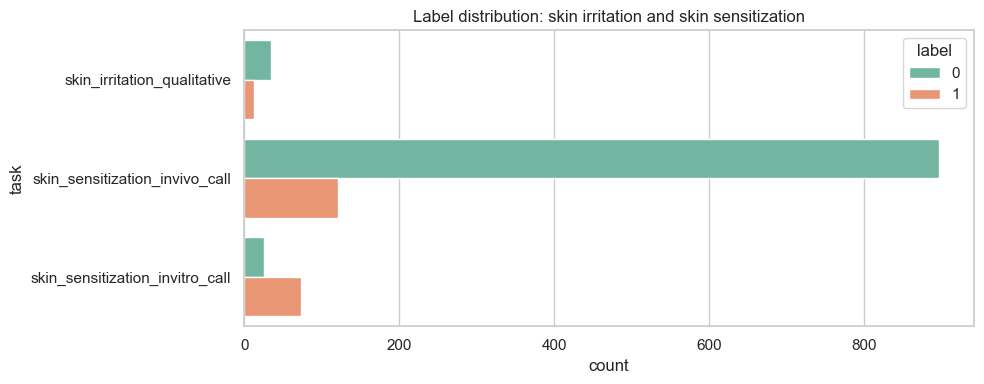

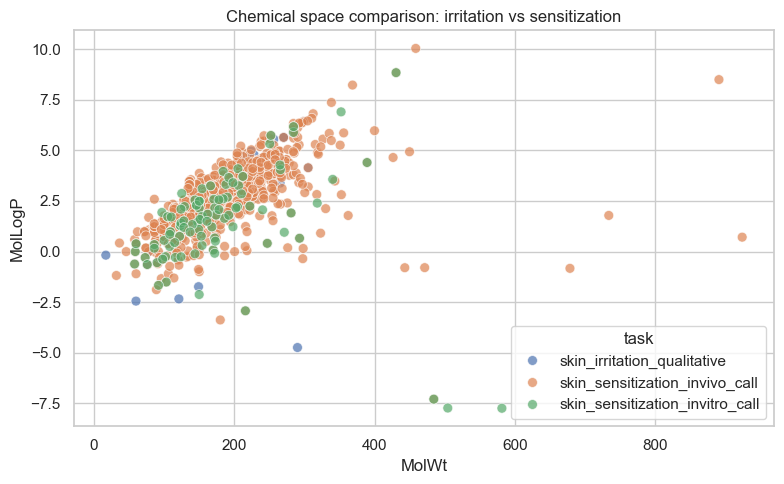

In [16]:

plt.figure(figsize=(10, 4))
plot_df = skin_local_toxicity_dataset[['task', 'label']].dropna().copy()
plot_df['label'] = plot_df['label'].astype(int)
sns.countplot(data=plot_df, y='task', hue='label', palette='Set2')
plt.title('Label distribution: skin irritation and skin sensitization')
plt.xlabel('count')
plt.ylabel('task')
plt.tight_layout()
plt.show()

if {'MolWt', 'MolLogP', 'task'}.issubset(skin_local_toxicity_dataset.columns):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=skin_local_toxicity_dataset,
        x='MolWt',
        y='MolLogP',
        hue='task',
        alpha=0.7,
        s=50,
    )
    plt.title('Chemical space comparison: irritation vs sensitization')
    plt.tight_layout()
    plt.show()


## 9. 데이터 시각화

채점 기준의 시각화 항목에 맞춰 라벨 분포, endpoint 분포, 주요 descriptor 분포, 구조 관련 descriptor 관계를 확인합니다.


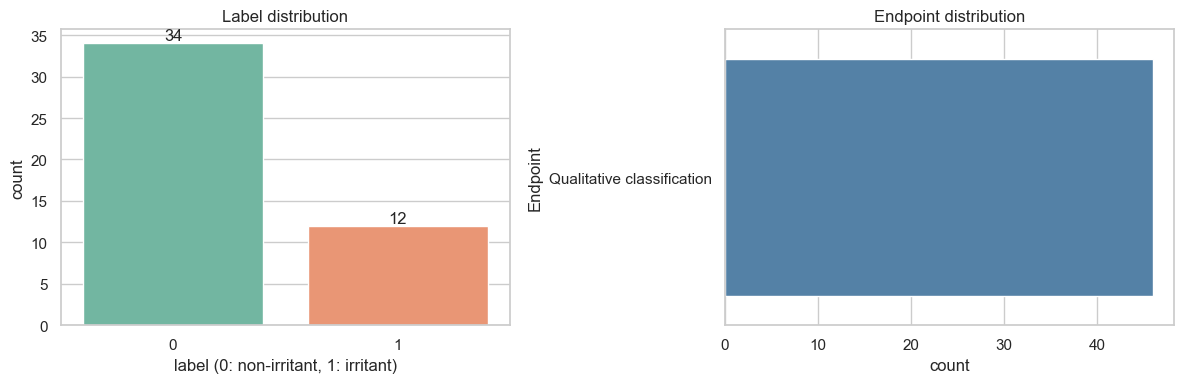

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=clean_df, x='label', ax=axes[0], palette='Set2')
axes[0].set_title('Label distribution')
axes[0].set_xlabel('label (0: non-irritant, 1: irritant)')
axes[0].set_ylabel('count')
for container in axes[0].containers:
    axes[0].bar_label(container)

if 'Endpoint' in clean_df.columns:
    endpoint_counts = clean_df['Endpoint'].value_counts().head(8)
    sns.barplot(x=endpoint_counts.values, y=endpoint_counts.index, ax=axes[1], color='steelblue')
    axes[1].set_title('Endpoint distribution')
    axes[1].set_xlabel('count')
    axes[1].set_ylabel('Endpoint')
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()


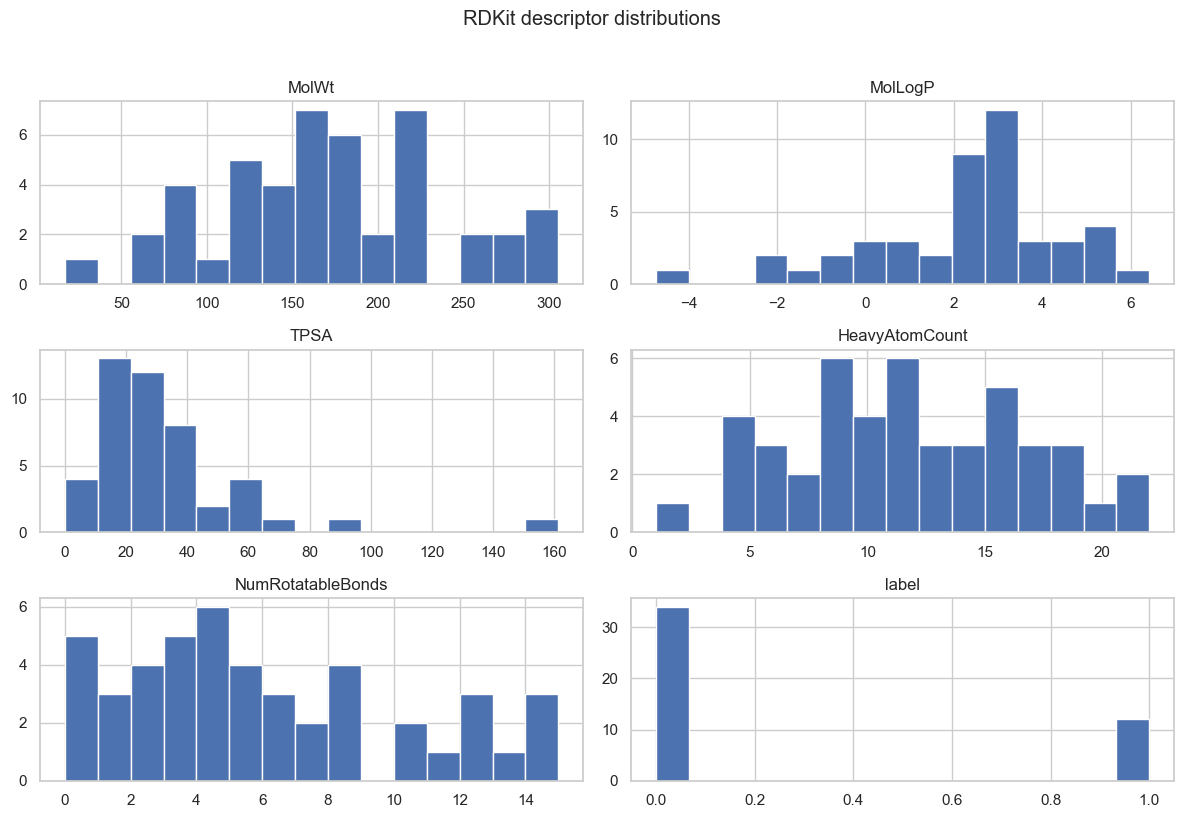

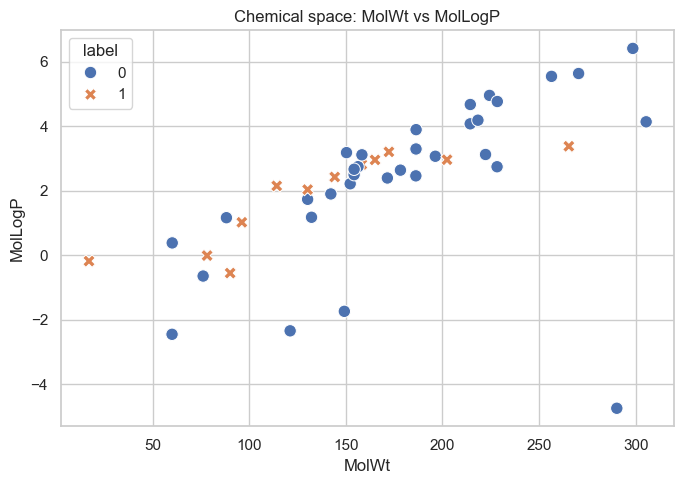

In [18]:
plot_cols = [c for c in ['MolWt', 'MolLogP', 'TPSA', 'HeavyAtomCount', 'NumRotatableBonds'] if c in rdkit_dataset.columns]

if plot_cols:
    rdkit_dataset[plot_cols + ['label']].hist(figsize=(12, 8), bins=15)
    plt.suptitle('RDKit descriptor distributions', y=1.02)
    plt.tight_layout()
    plt.show()

if {'MolWt', 'MolLogP', 'label'}.issubset(rdkit_dataset.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=rdkit_dataset, x='MolWt', y='MolLogP', hue='label', style='label', s=80)
    plt.title('Chemical space: MolWt vs MolLogP')
    plt.tight_layout()
    plt.show()


label,0,1
MolWt,183.280000,136.104917
MolLogP,2.490603,1.855962
TPSA,33.577059,32.036667
HeavyAtomCount,12.676471,8.833333
NumHAcceptors,1.970588,1.333333
NumHDonors,0.764706,0.583333
RingCount,0.411765,0.083333


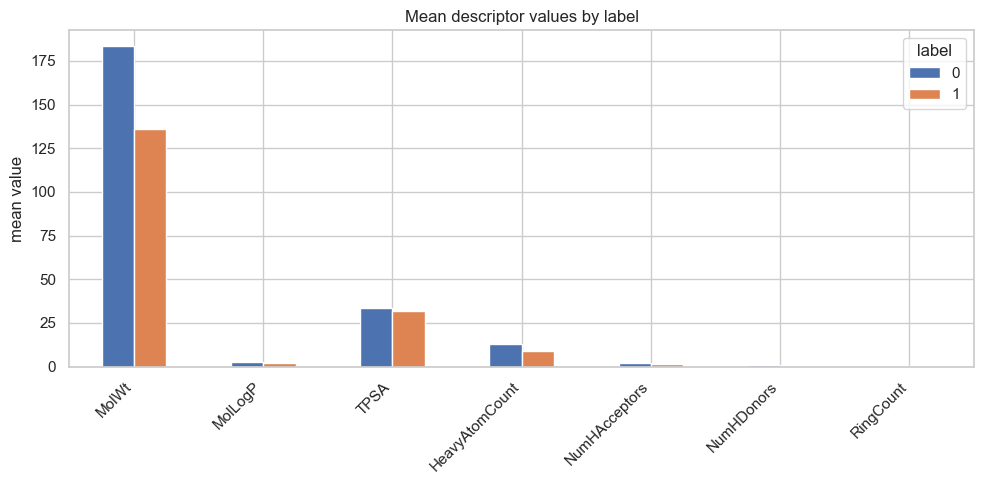

In [19]:
candidate_cols = [c for c in ['MolWt', 'MolLogP', 'TPSA', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'RingCount'] if c in rdkit_dataset.columns]

if candidate_cols:
    label_means = rdkit_dataset.groupby('label')[candidate_cols].mean().T
    display(label_means)

    label_means.plot(kind='bar', figsize=(10, 5))
    plt.title('Mean descriptor values by label')
    plt.ylabel('mean value')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## 10. 모델링 전 descriptor 품질 점검

수업의 feature preprocessing 흐름처럼, NaN이 포함된 descriptor와 표준편차가 너무 작은 descriptor를 확인합니다. 이 결과는 이후 `SelectKBest`, Logistic Regression, SVM, Random Forest, XGBoost 등에 넣기 전의 기본 점검입니다.


In [20]:
non_feature_cols = ['Chemical_Name', 'SMILES', 'standardized_smi', 'label']
X_desc = rdkit_dataset.drop(columns=[c for c in non_feature_cols if c in rdkit_dataset.columns])
y = rdkit_dataset['label']

nan_cols = X_desc.columns[X_desc.isna().any()].tolist()
X_no_nan = X_desc.dropna(axis=1)
low_std_cols = X_no_nan.columns[X_no_nan.std(numeric_only=True) < 0.01].tolist()
X_model_ready = X_no_nan.drop(columns=low_std_cols)

print('원본 descriptor shape:', X_desc.shape)
print('NaN 포함 descriptor 수:', len(nan_cols))
print('저분산 descriptor 수(std < 0.01):', len(low_std_cols))
print('모델 입력 가능 descriptor shape:', X_model_ready.shape)

if nan_cols:
    print('NaN 포함 descriptor 예시:', nan_cols[:10])
if low_std_cols:
    print('저분산 descriptor 예시:', low_std_cols[:10])


원본 descriptor shape: (46, 217)
NaN 포함 descriptor 수: 0
저분산 descriptor 수(std < 0.01): 64
모델 입력 가능 descriptor shape: (46, 153)
저분산 descriptor 예시: ['NumRadicalElectrons', 'PEOE_VSA13', 'SMR_VSA2', 'SMR_VSA8', 'SlogP_VSA7', 'SlogP_VSA9', 'EState_VSA11', 'NumAliphaticHeterocycles', 'NumAmideBonds', 'NumBridgeheadAtoms']


SelectKBest 상위 10개 descriptor:


,descriptor,score
20,BCUT2D_CHGLO,8.017671
142,fr_ester,6.260870
31,Chi1,5.945156
130,fr_C_O_noCOO,5.934624
22,BCUT2D_LOGPLOW,5.796537
99,HeavyAtomCount,5.678251
45,LabuteASA,5.632066
25,AvgIpc,5.561846
28,Chi0,5.520919
120,MolMR,5.482575


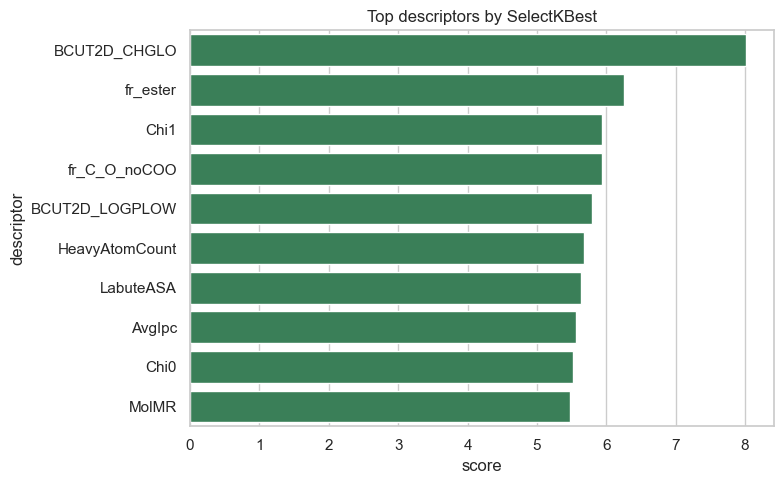

In [21]:
try:
    from sklearn.feature_selection import SelectKBest, f_classif

    k = min(10, X_model_ready.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_model_ready, y)

    feature_scores = pd.DataFrame({
        'descriptor': X_model_ready.columns,
        'score': selector.scores_,
    }).sort_values('score', ascending=False).head(k)

    print(f'SelectKBest 상위 {k}개 descriptor:')
    display(feature_scores)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=feature_scores, x='score', y='descriptor', color='seagreen')
    plt.title('Top descriptors by SelectKBest')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('SelectKBest 점검을 건너뜁니다:', type(exc).__name__, exc)


## 11. 결과 요약

- 원본 데이터에서 사람 대상 Chemical 피부 자극 데이터를 선택했습니다.
- SMILES 결측, CXSMILES, RDKit 변환 실패, 라벨 충돌, 중복 표준화 SMILES를 정리했습니다.
- RDKit 2D descriptor와 Morgan fingerprint를 계산했습니다.
- 최종 skin irritation 파일 `final_dataset_descriptors.csv`를 저장했습니다.
- 추가 데이터 다양성은 cancer/endocrine/eye 대신 관련성이 더 높은 `skin_sensitization.xlsx`로 구성했습니다.
- Skin irritation과 skin sensitization은 같은 endpoint는 아니지만, 둘 다 피부 노출 후 국소 피부 독성과 관련되므로 함께 비교할 수 있습니다.
- 통합 파일은 `final_skin_irritation_sensitization_descriptors.csv`로 저장했습니다.
- 이후 모델 개발 시에는 task별로 나누어 분석하거나, `task` 컬럼을 유지한 multi-task 보조 데이터셋으로 사용할 수 있습니다.
